In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [9]:
from autograd import Value, label_encoder, binary_cross_entropy, MLP, ParameterTracker
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
X, y = load_iris(return_X_y=True, as_frame=True)

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
# creating  binary classification for iris setosa 
"""
y = 0, iris-setosa
y = 1, iris-versicolor
y  = 2, iris-virginica
"""
y_true = (y == 0).astype(int)
y_true = label_encoder(y_true)

In [6]:
print(X.shape)
print(y_true.shape)

(150, 4)
(150, 1)


In [7]:
def train_with_tracking(model, X, y, learning_rate=0.01, num_iterations=100):
    """
    main trining loop with parameter and loss tracking.
    Args:
        model: MLP model
        X: input features (n samples, n features)
        y: target feature(n_sampels, 1/n_features(for multinomial classification))
        learning_rate: alpha_value for smooth parameter update
        num_iterations: number of training iterations.  
    """
    tracker = ParameterTracker()
    for iteration in range(num_iterations):
        # forward pass
        predictions = model(X)
        loss = binary_cross_entropy(y, predictions)
        tracker.record_iteration(iteration, loss, model)
        model.zero_grad()
        loss.backward()
        tracker.record_gradients(model)
        for param in model.parameters():
            param.data += -learning_rate * param.grad

        if iteration % 20 == 0:
            print(f"Iteration {iteration}/{num_iterations}: Loss{loss.data : .4f}")
    return tracker

In [8]:
custom_model = MLP(4, [3,1],['relu','sigmoid'])
tracker = train_with_tracking(custom_model, X, y, num_iterations=1000)

Iteration 0/1000: Loss 0.3900
Iteration 20/1000: Loss 0.3410
Iteration 40/1000: Loss 0.3030
Iteration 60/1000: Loss 0.2729
Iteration 80/1000: Loss 0.2484
Iteration 100/1000: Loss 0.2284
Iteration 120/1000: Loss 0.2117
Iteration 140/1000: Loss 0.1971
Iteration 160/1000: Loss 0.1842
Iteration 180/1000: Loss 0.1726
Iteration 200/1000: Loss 0.1620
Iteration 220/1000: Loss 0.1523
Iteration 240/1000: Loss 0.1434
Iteration 260/1000: Loss 0.1353
Iteration 280/1000: Loss 0.1279
Iteration 300/1000: Loss 0.1212
Iteration 320/1000: Loss 0.1149
Iteration 340/1000: Loss 0.1091
Iteration 360/1000: Loss 0.1037
Iteration 380/1000: Loss 0.0987
Iteration 400/1000: Loss 0.0940
Iteration 420/1000: Loss 0.0897
Iteration 440/1000: Loss 0.0856
Iteration 460/1000: Loss 0.0818
Iteration 480/1000: Loss 0.0783
Iteration 500/1000: Loss 0.0750
Iteration 520/1000: Loss 0.0719
Iteration 540/1000: Loss 0.0690
Iteration 560/1000: Loss 0.0663
Iteration 580/1000: Loss 0.0637
Iteration 600/1000: Loss 0.0613
Iteration 620/

In [17]:
def plot_loss_over_iteration(tracker, figsize=(12, 5)):
    """
    plot the loss over iterations
    """
    plt.figure(figsize=figsize)
    iterations = tracker.history['iteration']
    losses = tracker.history['loss']

    plt.plot(iterations, losses, linewidth=2.5,label='Trining Loss', color='red')
    plt.grid(True, alpha=0.3, linestyle='--')

    plt.title("Loss over the iterations", fontsize=16, fontweight='bold')
    plt.xlabel('Iterations',fontsize=12, fontweight="bold")
    plt.ylabel("Losses(Binary Cross Entropy)", fontsize=12, fontweight='bold')
    plt.legend(fontsize=11)
    plt.tight_layout()

    return plt.gcf()

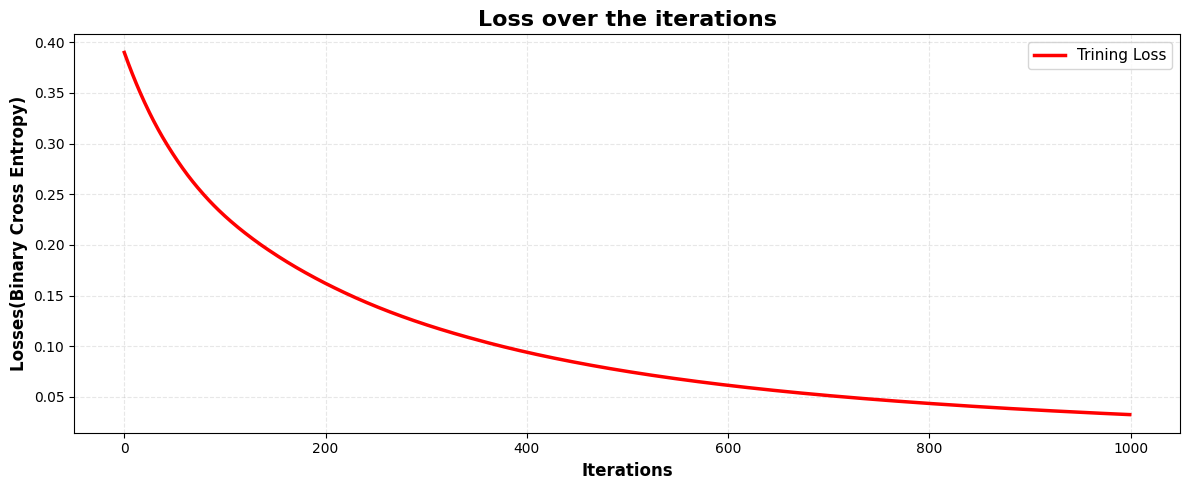

In [18]:
fig = plot_loss_over_iteration(tracker)

In [15]:
def plot_norm_over_iteration(tracker, figsize=(12, 5)):
    """
    plot the grad_norm over iterations
    """
    plt.figure(figsize=figsize)
    iterations = tracker.history['iteration']
    grad_norm = tracker.history['grad_norm']

    plt.plot(iterations, grad_norm, linewidth=2.5,label='Gradient Norm over Iterations', color='red')
    plt.grid(True, alpha=0.3, linestyle='--')

    plt.title("Gradient norm over the iterations", fontsize=16, fontweight='bold')
    plt.xlabel('Iterations',fontsize=12, fontweight="bold")
    plt.ylabel("Gradient Norm(L2)", fontweight='bold')
    plt.legend(fontsize=11)
    plt.tight_layout()

    return plt.gcf()

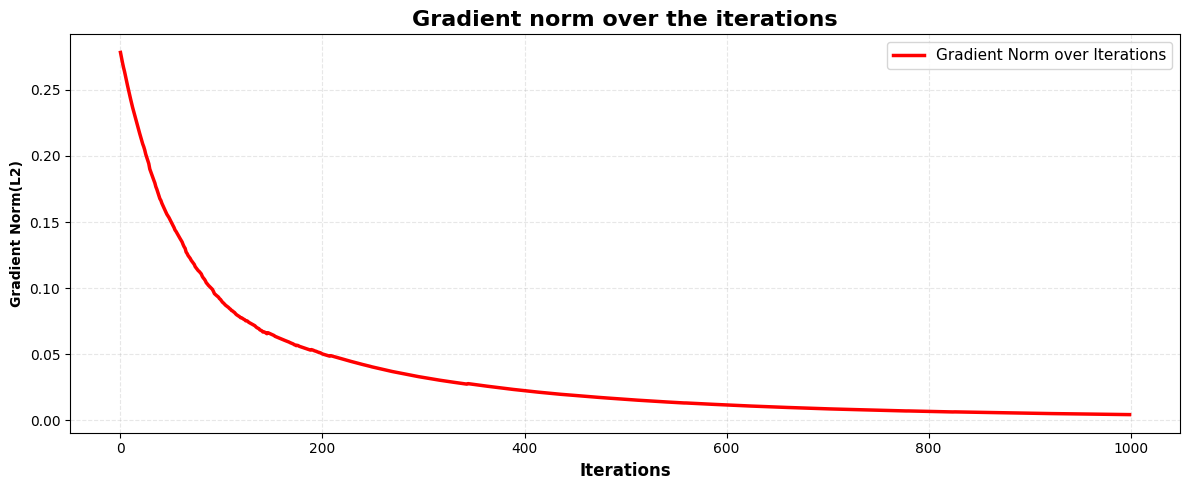

In [16]:
fig = plot_norm_over_iteration(tracker)

In [28]:
from autograd import Value
x  = Value(2.0)
y = x**2 +2

In [29]:
y.backward()
print("y_grad: " ,y.grad)
print("x_grad: ", x.grad)

y_grad:  1.0
x_grad:  4.0
